# Problem Set 5 for MSDM 5003

Author: LAN, Tianwei 藍天蔚<br>
ID: 21230969<br>
Email: tlanaa@connect.ust.hk

## (1) Construct a teacher network

The teacher network takes a vector $\xi$ as input and outputs a scalar $\sigma$, and performs 3 tasks during this process:

1. Compute y_field by input vector  $\xi$ and parameter matrices $B$ generated by Guassian distribution, which is a matrix mutiplication.
2. Activate t_field with error function.
3. get the output $\sigma$ by committee voting, which share the same weight.

In [7]:
import numpy as np
from scipy.special import erf

class TeacherSoftCommittee:

    def __init__(self, input_dim, hidden_num, seed):
        self.input_dim  = input_dim
        self.hidden_num = hidden_num
        rng = np.random.default_rng(seed)

        sigma = np.sqrt(1.0 / input_dim)          # sqrt(1/N)
        self.B = rng.normal(loc=0.0, scale=sigma, size=(hidden_num, input_dim))

    def forward(self, x: np.ndarray) -> float:
        x = np.atleast_2d(x)
        y_field = x @ self.B.T                    # y field matrix mutiplication
        g = erf(y_field / np.sqrt(2.0))           # hidden activation
        out = g.sum(axis=1)                       # committee sum
        return out.item() if out.size == 1 else out


Try out teacher network down here:

In [10]:
teacher = TeacherSoftCommittee(input_dim = 1000, hidden_num = 3, seed = 42)

np.random.seed(21230969)
batch_S = np.random.choice([-1, 1], size=(30, 1000))
labels = teacher.forward(batch_S)
print("30-sample average label:", labels.mean())

30-sample average label: 0.048704720342466645


## (2) Compute $T$ overlap

According to the definition of $T$ overlap, its matrix form should be the autocorrelation matrix obtained by self-multiplying the teacher field weight coefficient matrices. Its main diagonal should be close to 1 and other positions should be close to 0, that is, close to the identity matrix, and its order is the number of hidden nodes.

In [9]:
T = teacher.B @ teacher.B.T
T

array([[ 0.97840662, -0.00556355,  0.02944866],
       [-0.00556355,  1.03488789, -0.0293208 ],
       [ 0.02944866, -0.0293208 ,  1.03378116]])

Really close to identity matrix, isn't it?

## (3) Construct a student network

In [11]:
import numpy as np
from scipy.special import erf

class StudentSoftCommittee:

    def __init__(self, input_dim, hidden_num, seed):
        rng = np.random.default_rng(seed)
        sigma = 1.0 / input_dim          # sqrt(1/N²)
        self.J = rng.normal(loc=0.0, scale=sigma,
                            size=(hidden_num, input_dim))

    def forward(self, x):
        x = np.atleast_2d(x)
        h = x @ self.J.T
        g = erf(h / np.sqrt(2.0))
        return g.sum(axis=1).item() if g.shape[0] == 1 else g.sum(axis=1)

In [12]:
student = StudentSoftCommittee(input_dim = 1000, hidden_num = 3, seed = 42)

np.random.seed(21230969)
S = np.random.choice([-1, 1], size=(30, 1000))
labels = student.forward(S)
print("30-sample average label:", labels.mean())

30-sample average label: 0.004136682383392373


## (4) Online Learning
## (5) R and Q overlap calculation  
## (7) generalization error output

In [19]:
N            = 1000
H            = 3
eta          = 0.02
alpha_max    = 300
alpha_step   = 1.0 / N

teacher = TeacherSoftCommittee(N, H, seed=21230969)
student = StudentSoftCommittee(N, H, seed=21230969)

rng_data = np.random.default_rng(21230969)

# g'(x)
def g_prime(x):
    return np.sqrt(2.0 / np.pi) * np.exp(-x**2 / 2.0)

def generalization_error(n_mc=1000):
    x_mc = rng_data.normal(loc=0.0, scale=1.0, size=(n_mc, N))
    y_t  = teacher.forward(x_mc)
    y_s  = student.forward(x_mc)
    return np.mean((y_t - y_s)**2)

alphas, eps_g, Qs, Rs = [], [], [], []

alpha = 0.0
while alpha < alpha_max + 1e-8:
    # Generate a new sample
    x = rng_data.normal(loc=0.0, scale=1.0, size=N)
    o = teacher.forward(x)

    # Student forward
    h = x @ student.J.T
    g = erf(h / np.sqrt(2.0))
    y_s = g.sum()                   # stu output
    delta = o - y_s                 # [teacher-student]

    # δ_k = g'(h)*[teacher-student]
    delta_k = g_prime(h) * delta

    # Update：ΔJ_{ki} = (η/N)*δ_k*x_i
    student.J += (eta / N) * delta_k.reshape(H, 1) * x.reshape(1, N)

    # Record generalization error
    if int(alpha) != int(alpha + alpha_step):
        eps = generalization_error(n_mc=1000)
        alphas.append(alpha)
        eps_g.append(eps)
        
        Qs.append((student.J @ student.J.T).copy())
        Rs.append((teacher.B @ student.J.T).copy())

        print(f"α={alpha:6.2f}  ε_g={eps:.6f}")

    alpha += alpha_step

α=  1.00  ε_g=0.912800
α=  2.00  ε_g=0.774168
α=  3.00  ε_g=0.810500
α=  4.00  ε_g=0.695008
α=  5.00  ε_g=0.636734
α=  6.00  ε_g=0.583734
α=  7.00  ε_g=0.577171
α=  8.00  ε_g=0.521211
α=  9.00  ε_g=0.499448
α= 10.00  ε_g=0.484032
α= 11.00  ε_g=0.447401
α= 12.00  ε_g=0.398776
α= 13.00  ε_g=0.412722
α= 14.00  ε_g=0.375172
α= 15.00  ε_g=0.346250
α= 16.00  ε_g=0.330928
α= 17.00  ε_g=0.306818
α= 18.00  ε_g=0.286618
α= 19.00  ε_g=0.267309
α= 20.00  ε_g=0.277399
α= 21.00  ε_g=0.227007
α= 22.00  ε_g=0.232121
α= 23.00  ε_g=0.212290
α= 24.00  ε_g=0.210046
α= 25.00  ε_g=0.215039
α= 26.00  ε_g=0.187606
α= 27.00  ε_g=0.175647
α= 28.00  ε_g=0.172132
α= 29.00  ε_g=0.166210
α= 30.00  ε_g=0.151001
α= 31.00  ε_g=0.165116
α= 32.00  ε_g=0.152236
α= 33.00  ε_g=0.140671
α= 34.00  ε_g=0.118706
α= 35.00  ε_g=0.131541
α= 36.00  ε_g=0.127491
α= 37.00  ε_g=0.114751
α= 38.00  ε_g=0.119123
α= 39.00  ε_g=0.108390
α= 40.00  ε_g=0.107432
α= 41.00  ε_g=0.105110
α= 42.00  ε_g=0.099725
α= 43.00  ε_g=0.096776
α= 44.00  ε

## (6) Plot R

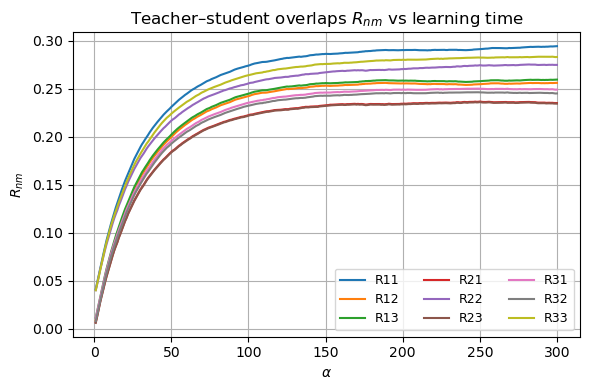

Specialization (teacher → student unit):
Teacher hidden unit 1  ↔  Student hidden unit 1
Teacher hidden unit 2  ↔  Student hidden unit 2
Teacher hidden unit 3  ↔  Student hidden unit 3


In [29]:
import matplotlib.pyplot as plt

alphas = np.asarray(alphas)
Rs     = np.asarray(Rs)

plt.figure(figsize=(6,4))
for n in range(3):
    for m in range(3):
        plt.plot(alphas, Rs[:, n, m], label=f'R{n+1}{m+1}')

plt.xlabel(r'$\alpha$')
plt.ylabel(r'$R_{nm}$')
plt.title('Teacher–student overlaps $R_{nm}$ vs learning time')
plt.legend(ncol=3, fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()

# Specialization report
R_final = Rs[-1]
special = np.argmax(R_final, axis=1)
print("Specialization (teacher → student unit):")
for t_idx, s_idx in enumerate(special, 1):
    print(f"Teacher hidden unit {t_idx}  ↔  Student hidden unit {s_idx + 1}")

The figure shows that R11, R22, and R33 are significantly higher than other values, and the hidden units of students and teachers form a one-to-one relationship. Therefore, it can be concluded that the student network has achieved learning of the teacher network under given conditions.

## (8) Plot Generalization error with R on simulation and theoretical calculation

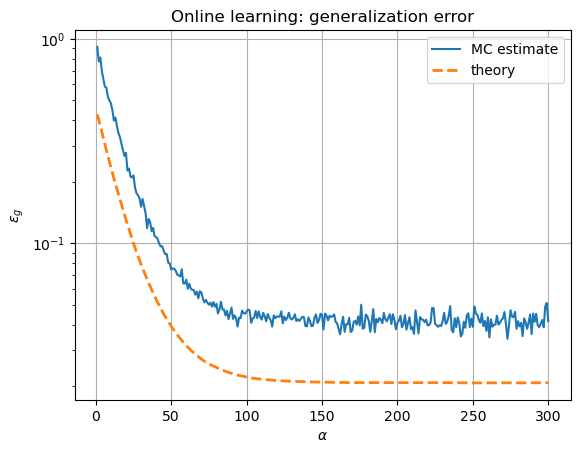

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def theoretical_eps_g(Q, R, T):
    term1 = 0.0
    for i in range(3):
        for k in range(3):
            denom = np.sqrt((1 + Q[i,i]) * (1 + Q[k,k]))
            term1 += np.arcsin(Q[i,k] / denom)

    term2 = 0.0
    for n in range(3):
        for m in range(3):
            denom = np.sqrt((1 + T[n,n]) * (1 + T[m,m]))
            term2 += np.arcsin(T[n,m] / denom)

    term3 = 0.0
    for i in range(3):
        for n in range(3):
            denom = np.sqrt((1 + Q[i,i]) * (1 + T[n,n]))
            term3 += np.arcsin(R[i,n] / denom)

    return (term1 + term2 - 2 * term3) / np.pi


T_fix = teacher.B @ teacher.B.T
theory_eps = [theoretical_eps_g(Q, R, T_fix) for Q, R in zip(Qs, Rs)]


plt.semilogy(alphas, eps_g, label='MC estimate')
plt.semilogy(alphas, theory_eps, label='theory', lw=2, ls='--')
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\varepsilon_g$')
plt.title('Online learning: generalization error')
plt.legend()
plt.grid(True)
plt.show()

The generalization error follows the trend of the theoretical value but has an absolute error. This is because the theoretical curve assumes infinite dimensions and noise-free gradient flow, while the simulation uses finite N and single-sample updates, so finite-size fluctuations and gradient noise push the measured error slightly above the ideal line.